# Toric-code-specific NES sampler

This notebook tests the flux-free initialization and runs the star/winding-loop Metropolis kernel. It is for the four toric-code ground states on a torus.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / 'Desktop' / 'Master Thesis' / 'NES_Spins'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
from nes_lattice.lattice import toric_code_move_masks, toric_code_plaquette_values
from nes_lattice.train import TrainConfig, train, save_history
from nes_lattice.plots import plot_history, plot_diagnostics, print_final


## 1. Static move check
Both star masks and winding-loop masks must preserve every plaquette value $B_p$.


In [2]:
shape = (4, 4)
star_masks, loop_masks = toric_code_move_masks(shape)
base = np.ones((1, 2 * shape[0] * shape[1]), dtype=np.int8)

for label, masks in [('stars', star_masks), ('loops', loop_masks)]:
    moved = np.concatenate([base * (1 - 2 * mask)[None, :] for mask in masks], axis=0)
    bp = toric_code_plaquette_values(moved, shape)
    assert np.all(bp == 1), f'{label} did not preserve B_p=+1'

print('star masks:', star_masks.shape)
print('loop masks:', loop_masks.shape)
print('All star and winding-loop moves preserve B_p=+1.')


star masks: (16, 32)
loop masks: (2, 32)
All star and winding-loop moves preserve B_p=+1.


## 2. First 4x4 ground-state baseline
Use `k=1` first. The sampler uses 90% star moves and 10% winding loops.


In [4]:
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian='toric_code',
    k=1,
    Je=1.0,
    Jm=1.0,

    model='vit',
    vit_patch_size=1,
    vit_d_model=64,
    vit_num_layers=4,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=False,

    steps=2000,
    lr=5e-4,
    grad_clip=1.0,
    n_chains=256,
    n_samples=16,
    sweep_steps=32,
    burn_in=320,

    toric_loop_prob=0.10,
    toric_single_flip_prob=0.0,
    toric_cover_sectors=True,

    print_every=250,
    eval_exact_if_sites_leq=12,
    eval_chains=256,
    eval_samples=64,
    reference='auto',
    seed=0,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k1_vit_toricmoves.json'
save_history(history, save_path, cfg)
print('saved to:', save_path)


{'step': 0, 'loss_sum': -29.85521697998047, 'train_energy_estimator': nan, 'energies': [-29.85521697998047], 'reference': [-32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [2.1447830200195312], 'trace_error': 2.1447830200195312, 'condition_number_S': 1.0, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.6133880615234375, 'burn_accept_rate': 0.6185302734375, 'burn_loop_accept_rate': 0.6093469262123108, 'burn_loop_move_fraction': 0.10186767578125, 'burn_single_flip_accept_rate': 0.0, 'burn_single_flip_move_fraction': 0.0, 'burn_star_accept_rate': 0.61957186460495, 'burn_star_move_fraction': 0.89813232421875, 'loop_accept_rate': 0.6104022264480591, 'loop_move_fraction': 0.100004196166

## 3. Read the sampler diagnostics and plot


energies: [-32.00001907348633]
train_energy_estimator: -32.0
sampler_accept_rate: 0.9998626708984375
sampler_star_accept_rate: 0.999856173992157
sampler_loop_accept_rate: 0.999922513961792
sampler_star_move_fraction: 0.901519775390625
sampler_loop_move_fraction: 0.098480224609375
invalid_bundle_fraction: 0.0
File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/NES_Spins/results/sampled_nes_toric_4x4_k1_vit_toricmoves.json
Config:             {'shape': [4, 4], 'hamiltonian': 'toric_code', 'k': 1, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'vit', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'vit_patch_size': 1, 'vit_d_model': 64, 'vit_num_layers': 4, 'vit_num_heads': 4, 'vit_mlp_ratio': 2, 'vit_use_positional_embeddings': False, 'vit_log_amplitude_clip': 20.0, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 2000, 'lr': 0.0005, 'n_chains': 256, 'n_samples': 16, 'sweep_steps': 32, 'burn_in': 320, 'grad_

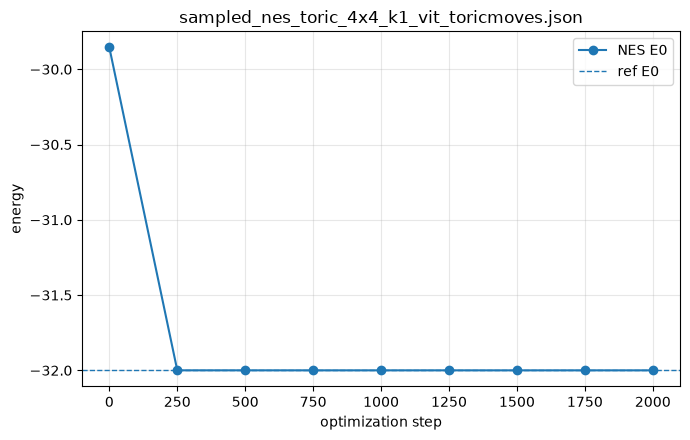

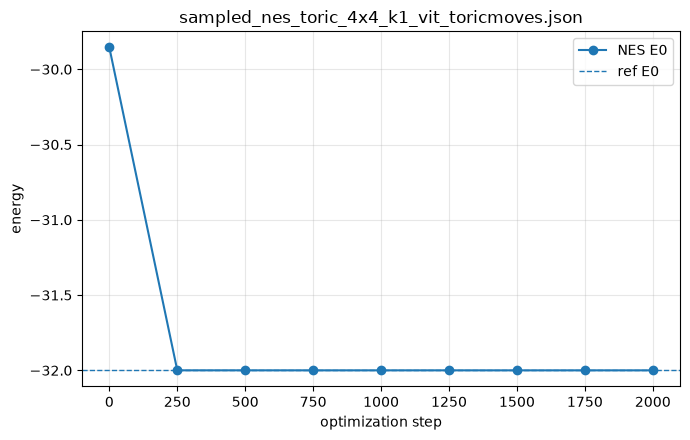

In [ ]:
final = history[-1]
for key in [
    'energies',
    'train_energy_estimator',
    'sampler_accept_rate',
    'sampler_star_accept_rate',
    'sampler_loop_accept_rate',
    'sampler_star_move_fraction',
    'sampler_loop_move_fraction',
    'invalid_bundle_fraction',
]:
    print(f'{key}:', final.get(key))

print_final(save_path)
fig, ax = plot_history(save_path)


## 4. Fourfold ground space
Run this only after the `k=1` baseline is behaving reasonably.


In [9]:
cfg4 = TrainConfig(
    shape=(4, 4),
    hamiltonian='toric_code',
    k=4,
    Je=1.0,
    Jm=1.0,

    model='vit',
    vit_patch_size=1,
    vit_d_model=64,
    vit_num_layers=4,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=False,

    steps=5000,
    lr=2e-4,
    grad_clip=1.0,
    n_chains=36,
    n_samples=16,
    sweep_steps=32,
    burn_in=320,

    toric_loop_prob=0.10,
    toric_single_flip_prob=0.0,
    toric_cover_sectors=True,

    print_every=500,
    eval_exact_if_sites_leq=12,
    eval_chains=256,
    eval_samples=64,
    reference='auto',
    seed=1,
)

params4, history4 = train(cfg4)
save_path4 = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k4_vit_toricmoves.json'
save_history(history4, save_path4, cfg4)
print('saved to:', save_path4)


{'step': 0, 'loss_sum': -107.25477450136303, 'train_energy_estimator': nan, 'energies': [-31.597734949216875, -26.989729198689155, -24.785999006795663, -23.881311346661334], 'reference': [-32.0, -32.0, -32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [0.40226505078312513, 5.0102708013108455, 7.214000993204337, 8.118688653338666], 'trace_error': 20.74522549863697, 'condition_number_S': 36.83647294898163, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.7792129516601562, 'burn_accept_rate': 0.779492199420929, 'burn_loop_accept_rate': 0.7702503204345703, 'burn_loop_move_fraction': 0.09946288913488388, 'burn_single_flip_accept_rate': 0.0, 'burn_single_flip_move_fraction': 0.0, '

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/NES_Spins/results/sampled_nes_toric_4x4_k4_vit_toricmoves.json
Config:             {'shape': [4, 4], 'hamiltonian': 'toric_code', 'k': 4, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'vit', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'vit_patch_size': 1, 'vit_d_model': 64, 'vit_num_layers': 4, 'vit_num_heads': 4, 'vit_mlp_ratio': 2, 'vit_use_positional_embeddings': False, 'vit_log_amplitude_clip': 20.0, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 5000, 'lr': 0.0002, 'n_chains': 36, 'n_samples': 16, 'sweep_steps': 32, 'burn_in': 320, 'grad_clip': 1.0, 'toric_loop_prob': 0.1, 'toric_single_flip_prob': 0.0, 'toric_cover_sectors': True, 'print_every': 500, 'eval_exact_if_sites_leq': 12, 'eval_samples': 64, 'eval_chains': 256, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-06, 'seed': 1}
Final NES energies: [

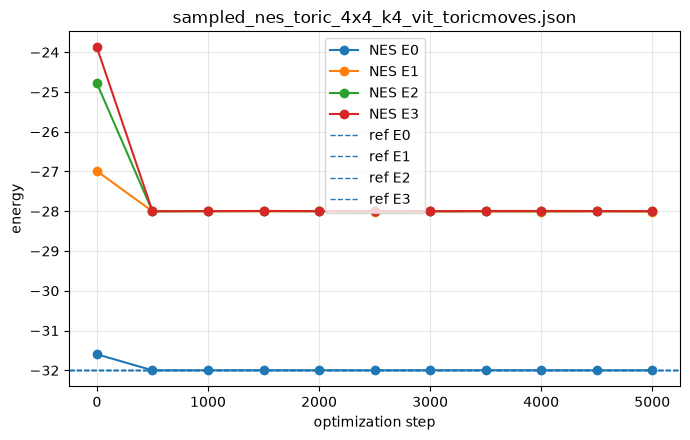

In [11]:
print_final(save_path4)
fig, ax = plot_history(save_path4)

{'step': 0, 'loss_sum': -5.046140874487082, 'train_energy_estimator': nan, 'energies': [-3.96058978933592, -1.0679328354467736, -0.11862695719657197, 0.10100870749218366], 'reference': [-8.0, -8.0, -8.0, -8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [4.03941021066408, 6.932067164553226, 7.881373042803428, 8.101008707492184], 'trace_error': 26.953859125512917, 'condition_number_S': 18.812721640306787, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'S_min_eig': 924.7705936242915, 'S_max_eig': 17397.451758995063, 'S_rank': 4, 'S_floor': 1.7397451758995063e-06, 'S_num_clipped': 0, 'S_eigenvalues': [924.7705936242915, 1522.8450883809799, 11794.662417398096, 17397.451758995063], 'method': 'exact_span

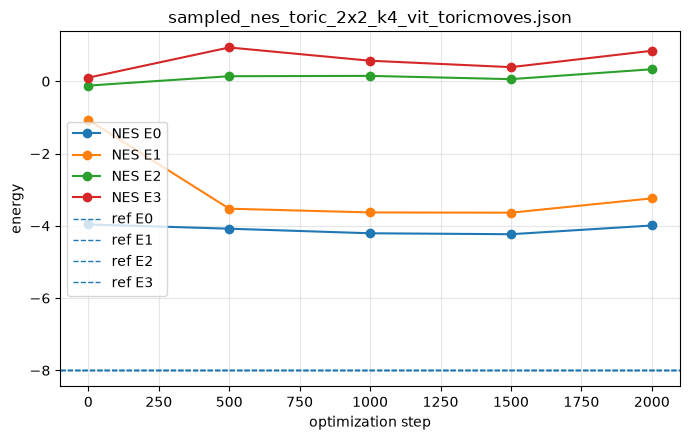

In [20]:
cfg2 = TrainConfig(
    shape=(2, 2),
    hamiltonian='toric_code',
    k=4,
    Je=1.0,
    Jm=1.0,

    model='vit',
    vit_patch_size=1,
    vit_d_model=64,
    vit_num_layers=4,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=True,

    steps=2000,
    lr=5e-4,
    n_chains=128,
    n_samples=18,
    sweep_steps=32,
    burn_in=32,

    toric_loop_prob=0.0,
    toric_single_flip_prob=0.0,
    toric_cover_sectors=True,

    print_every=500,
    eval_exact_if_sites_leq=12,
    eval_chains=256,
    eval_samples=64,
    reference='auto',
    seed=1,
)

params2, history2 = train(cfg2)
save_path2 = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k4_vit_toricmoves.json'
save_history(history2, save_path2, cfg2)
print_final(save_path2)
fig, ax = plot_history(save_path2)

In [4]:
for rec in history2:
    print(
        rec["step"],
        "train:", rec.get("train_energy"),
        "energies:", rec["energies"],
        "condS:", rec.get("condition_number_S"),
        "rank:", rec.get("S_rank"),
        "accept:", rec.get("sampler_accept_rate"),
    )

0 train: None energies: [-1.8663444818436663] condS: 1.0 rank: None accept: nan
500 train: None energies: [-4.000084904827349] condS: 1.0 rank: None accept: 0.0
1000 train: None energies: [-4.0000656634522365] condS: 1.0 rank: None accept: 0.0
1500 train: None energies: [-4.0000657273956275] condS: 1.0 rank: None accept: 0.0
2000 train: None energies: [-4.000071844839097] condS: 1.0 rank: None accept: 0.0


# Back to RBMs

{'step': 0, 'loss_sum': -19.70650888587851, 'train_energy_estimator': nan, 'energies': [-7.9873486524188255, -4.047424010841243, -3.9979684370998085, -3.6737677855186344], 'reference': [-8.0, -8.0, -8.0, -8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [0.012651347581174477, 3.952575989158757, 4.002031562900191, 4.326232214481365], 'trace_error': 12.29349111412149, 'condition_number_S': 1907.9705172162908, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.932464599609375, 'burn_accept_rate': 0.93115234375, 'burn_loop_accept_rate': 0.9474746584892273, 'burn_loop_move_fraction': 0.04833984375, 'burn_single_flip_accept_rate': 0.0, 'burn_single_flip_move_fraction': 0.0, 'burn_star_accept

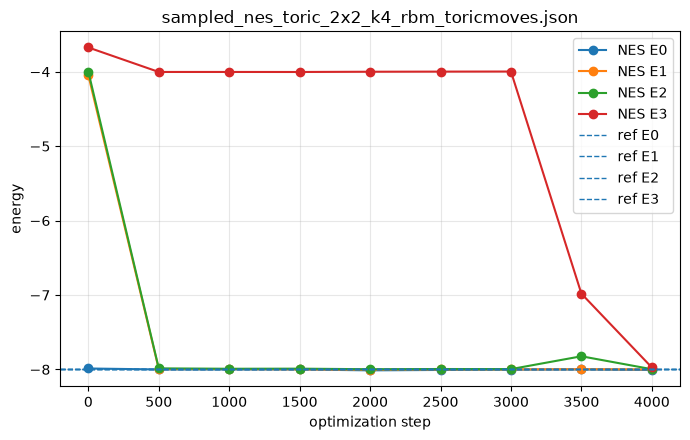

In [25]:
cfg = TrainConfig(
    shape=(2, 2),
    hamiltonian="toric_code",
    k=4,
    model="rbm",              
    rbm_hidden=128,
    Je=1.0,
    Jm=1.0,

    steps=4000,
    lr=1e-4,
    n_chains=256,
    n_samples=32,
    sweep_steps=64,
    burn_in=320,

    toric_loop_prob=0.05,
    toric_single_flip_prob=0,
    toric_cover_sectors=True,

    print_every=500,
    eval_exact_if_sites_leq=0,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k4_rbm_toricmoves.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'loss_sum': -115.50341010509317, 'train_energy_estimator': nan, 'energies': [-31.934940037692893, -27.895251144988798, -27.880958265374726, -27.792260657036756], 'reference': [-32.0, -32.0, -32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [0.06505996230710664, 4.104748855011202, 4.119041734625274, 4.207739342963244], 'trace_error': 12.496589894906833, 'condition_number_S': 61.87176480917753, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.9095993041992188, 'burn_accept_rate': 0.911938488483429, 'burn_loop_accept_rate': 0.8951691389083862, 'burn_loop_move_fraction': 0.050537109375, 'burn_single_flip_accept_rate': 0.0, 'burn_single_flip_move_fraction': 0.0, 'burn_

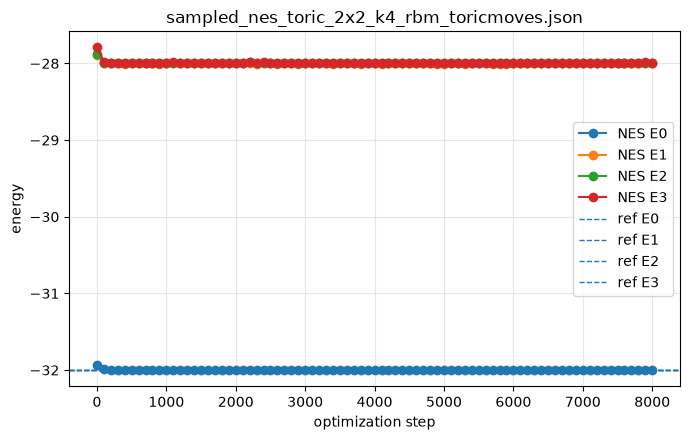

In [27]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=4,
    model="rbm",              
    rbm_hidden=128,
    Je=1.0,
    Jm=1.0,

    steps=8000,
    lr=5e-4,
    n_chains=256,
    n_samples=32,
    sweep_steps=64,
    burn_in=320,

    toric_loop_prob=0.05,
    toric_single_flip_prob=0,
    toric_cover_sectors=True,

    print_every=100,
    eval_exact_if_sites_leq=12,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k4_rbm_toricmoves.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

In [4]:
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian="toric_code",
    k=4,
    model="toric_rbm",
    rbm_hidden=256,
    init_scale=0.02,

    steps=500,
    lr=1e-4,
    grad_clip=1.0,
    n_chains=512,
    n_samples=64,
    sweep_steps=128,
    burn_in=1024,

    toric_loop_prob=0.0,
    toric_single_flip_prob=0.0,
    toric_cover_sectors=True,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k4_rbm_toricmoves.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

W0715 14:23:01.122341     198 subprocess_compilation.cc:242] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 6.1
W0715 14:23:01.122364     198 subprocess_compilation.cc:245] Used ptxas at /home/a/Anas.Roumeih/venv/nqs311/lib/python3.11/site-packages/nvidia/cu13/bin/ptxas


JaxRuntimeError: UNIMPLEMENTED: /home/a/Anas.Roumeih/venv/nqs311/lib/python3.11/site-packages/nvidia/cu13/bin/ptxas ptxas too old. Falling back to the driver to compile.

# FFN

{'step': 0, 'loss_sum': -23.923829968861888, 'train_energy_estimator': nan, 'energies': [-32.000000000006196, -2.3099741167765755e-06, -3.5704772519405653e-13, 8.076172341118776], 'reference': [-32.0, -32.0, -32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [6.195932655828074e-12, 31.999997690025882, 31.99999999999964, 40.07617234111878], 'trace_error': 104.0761700311381, 'condition_number_S': 999931.4462685729, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'accept_rate': 1.0, 'burn_accept_rate': 1.0, 'burn_loop_accept_rate': 1.0, 'burn_loop_move_fraction': 0.050537109375, 'burn_single_flip_accept_rate': 0.0, 'burn_single_flip_move_fraction': 0.0, 'burn_star_accept_rate': 1.0, 'burn_star_m

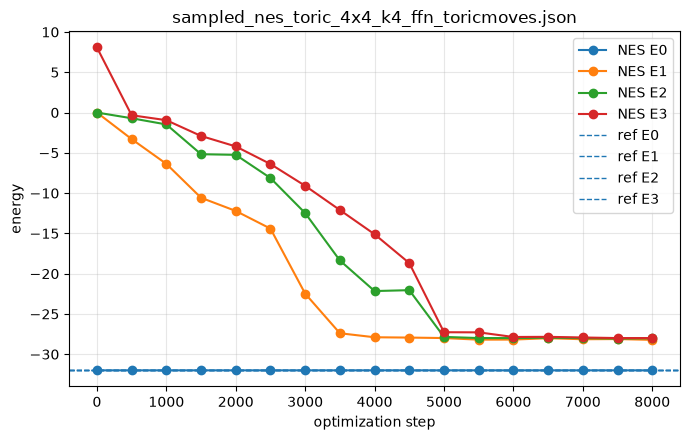

In [8]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=4,
    model="ffn",              
    hidden=(512,512,512),
    Je=1.0,
    Jm=1.0,
    init_scale=0.01,
    steps=8000,
    lr=5e-5,
    n_chains=256,
    n_samples=32,
    sweep_steps=64,
    burn_in=320,

    toric_loop_prob=0.05,
    toric_single_flip_prob=0,
    toric_cover_sectors=True,

    print_every=500,
    eval_exact_if_sites_leq=0,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k4_ffn_toricmoves.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)